# 프로젝트 : Spaceship Titanic

## 개요
우주선 **Spaceship Titanic** 승객 데이터를 활용하여, 각 승객이 사고로 인해 다른 차원으로
**이동(Transported)** 되었는지 여부를 예측하는 **이진 분류(Binary Classification)** 문제이다.

## 목표
- 체계적인 EDA를 통해 변수 간 관계와 결측 패턴을 파악한다.
- **도메인 규칙 기반 결측치 처리**와 **그룹 정보 기반 보간**으로 데이터 품질을 높인다.
- 의미 있는 **Feature Engineering** 으로 모델이 학습할 신호를 강화한다.
- **K-Fold 교차검증 + 다중 부스팅 모델 앙상블** 로 일반화 성능을 끌어올린다.
- **Kaggle Public Score 0.805 이상** 달성.

## 1. 라이브러리

In [1]:
# 데이터 처리 
import numpy as np
import pandas as pd

# 시각화 
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 메시지 숨김 
import warnings
warnings.filterwarnings('ignore')

# 전처리 & 검증 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

# 부스팅 모델
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# 재현성을 위한 랜덤 시드 고정
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
print('라이브러리 임포트 완료')

라이브러리 임포트 완료


## 2. 데이터 불러오기

Kaggle Spaceship Titanic 데이터셋을 읽는다.


In [2]:
train = pd.read_csv('./data/train.csv')
test = pd.read_csv('./data/test.csv')
sample_submission = pd.read_csv('./data/sample_submission.csv')

print('Train shape :', train.shape)
print('Test  shape :', test.shape)
train.head()

Train shape : (8693, 14)
Test  shape : (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## 3. 탐색적 데이터 분석 (EDA)

먼저 데이터의 전반적인 구조, 자료형, 기초 통계량을 확인한다.


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [4]:
train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


### 3-1. 타겟 변수 분포

`Transported` 의 클래스 균형을 확인한다. 불균형이 심하면 별도 샘플링 전략이 필요하다.


Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64


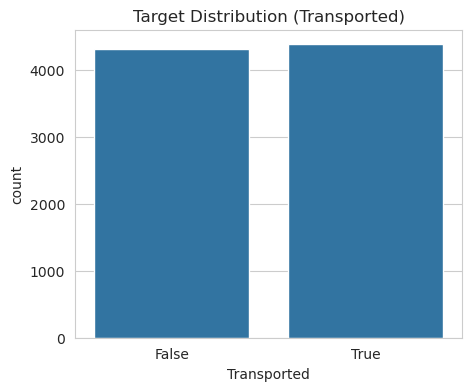

In [5]:
print(train['Transported'].value_counts(normalize=True))

plt.figure(figsize=(5, 4))
sns.countplot(x='Transported', data=train)
plt.title('Target Distribution (Transported)')
plt.show()

### 해석

`Transported` 는 True/False 가 거의 50:50 으로 균형을 이룬다.
따라서 오버/언더샘플링 없이 그대로 학습해도 무방하며, 평가지표인 **Accuracy** 가
이 문제에서 합리적인 지표가 된다.


### 3-2. 결측치 확인

각 변수의 결측 개수와 비율을 표와 그래프로 확인한다.


,Missing_Count,Missing_Ratio(%)
CryoSleep,217,2.50
ShoppingMall,208,2.39
VIP,203,2.34
HomePlanet,201,2.31
Name,200,2.30
Cabin,199,2.29
VRDeck,188,2.16
FoodCourt,183,2.11
Spa,183,2.11
Destination,182,2.09


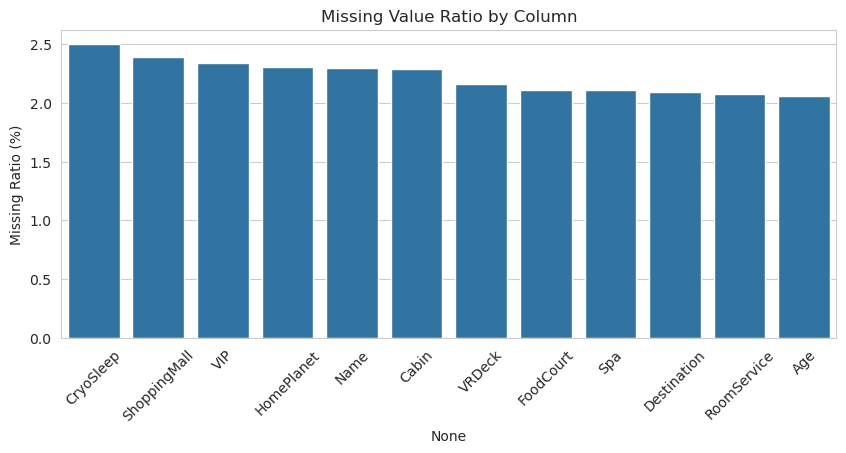

In [6]:
missing = train.isnull().sum()
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Ratio(%)': (missing / len(train) * 100).round(2)
})
missing_df = missing_df[missing_df['Missing_Count'] > 0] \
                .sort_values('Missing_Ratio(%)', ascending=False)
display(missing_df)

plt.figure(figsize=(10, 4))
sns.barplot(x=missing_df.index, y=missing_df['Missing_Ratio(%)'])
plt.xticks(rotation=45)
plt.ylabel('Missing Ratio (%)')
plt.title('Missing Value Ratio by Column')
plt.show()

### 해석

모든 변수의 결측 비율이 최대 약 2.5% 수준으로 낮다.  
행을 삭제하기보다는 변수 특성에 맞는 대체가 적절하다.  
단순 median/mode 일괄 대체 대신, 뒤에서 그룹 정보와 도메인 규칙을 활용한  
정교한 보간을 적용해 정보 손실을 줄인다.


### 3-3. 복합 변수 구조 파악 (PassengerId, Cabin)

두 변수는 여러 정보를 하나의 문자열에 담고 있어 분해가 필요하다.

In [7]:
print('PassengerId 예시')
print(train['PassengerId'].head(3).tolist())
print('\nCabin 분해 예시')
print(train['Cabin'].str.split('/', expand=True).head(3))

PassengerId 예시
['0001_01', '0002_01', '0003_01']

Cabin 분해 예시
   0  1  2
0  B  0  P
1  F  0  S
2  A  0  S


### 3-4. 소비(Spending) 변수와 CryoSleep 관계

`CryoSleep`(냉동수면) 상태인 승객은 우주선 시설을 이용할 수 없어
**소비액이 0** 이어야 한다는 강한 도메인 규칙이 존재한다. 이를 확인한다.


In [8]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
tmp = train.copy()
tmp['_TotalSpend'] = tmp[spend_cols].fillna(0).sum(axis=1)

print('CryoSleep 별 평균 총소비액:')
print(tmp.groupby('CryoSleep')['_TotalSpend'].mean())
print('\nCryoSleep=True 승객 중 소비액 0인 비율:',
      round((tmp.loc[tmp['CryoSleep'] == True, '_TotalSpend'] == 0).mean(), 4))

CryoSleep 별 평균 총소비액:
CryoSleep
False    2248.299687
True        0.000000
Name: _TotalSpend, dtype: float64

CryoSleep=True 승객 중 소비액 0인 비율: 1.0


### 해석  
`CryoSleep=True` 인 승객은 거의 전원이 소비액 0 이다.  
이 규칙은 **결측치 보간**(소비가 있으면 CryoSleep=False, 소비가 0이면 True로 추정)과  
**Feature Engineering**(NoSpend) 양쪽에 활용할 수 있는 강력한 신호다.


## 4. 전처리 & Feature Engineering

train/test 를 하나로 합쳐(`data`) 동일한 규칙으로 처리하면,
- 결측치 보간·인코딩 시 train/test 간 불일치(범주 누락 등)를 원천 차단하고,
- 그룹 기반 통계를 양쪽 데이터에 일관되게 적용할 수 있다.

In [9]:
SPEND_COLS = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# 정답 분리 (bool → int)
train_len = len(train)
y = train['Transported'].astype(int)

# train + test 통합 (정답 제거 후 세로 결합)
data = pd.concat(
    [train.drop('Transported', axis=1), test],
    axis=0,
    ignore_index=True
)
print('통합 data shape :', data.shape)

통합 data shape : (12970, 13)


### 4-1. 복합 변수 분해

- `PassengerId` → `GroupID`(그룹번호) → `GroupSize`(그룹 인원수)
- `Cabin` → `Deck`, `CabinNum`(숫자형), `Side`


In [10]:
# PassengerId → GroupID, GroupSize
data['GroupID'] = data['PassengerId'].str.split('_').str[0]
data['GroupSize'] = data.groupby('GroupID')['GroupID'].transform('count')

# Cabin → Deck / CabinNum / Side
cabin_split = data['Cabin'].str.split('/', expand=True)
data['Deck'] = cabin_split[0]
data['CabinNum'] = pd.to_numeric(cabin_split[1], errors='coerce')
data['Side'] = cabin_split[2]

data[['PassengerId', 'GroupID', 'GroupSize', 'Deck', 'CabinNum', 'Side']].head()

,PassengerId,GroupID,GroupSize,Deck,CabinNum,Side
0,0001_01,0001,1,B,0.0,P
1,0002_01,0002,1,F,0.0,S
2,0003_01,0003,2,A,0.0,S
3,0003_02,0003,2,A,0.0,S
4,0004_01,0004,1,F,1.0,S


### 4-2. 그룹 기반 결측치 보간 (핵심 개선 1)

같은 `GroupID`(가족/동행)는 **출발지·목적지·객실(Deck/Side)** 를 공유하는 경우가 많다.
따라서 그룹 내 **최빈값/중앙값**으로 먼저 채우면, 단순 전체 통계 대체보다 훨씬 정확하다.


In [11]:
# 범주형: 그룹 내 최빈값으로 보간
for col in ['HomePlanet', 'Destination', 'Deck', 'Side']:
    group_mode = data.groupby('GroupID')[col].transform(
        lambda s: s.mode().iloc[0] if s.notna().any() else np.nan
    )
    data[col] = data[col].fillna(group_mode)

# 객실 번호: 그룹 내 중앙값으로 보간 (같은 그룹은 인접 객실일 가능성 올라감)
group_cabinnum = data.groupby('GroupID')['CabinNum'].transform('median')
data['CabinNum'] = data['CabinNum'].fillna(group_cabinnum)

print('그룹 보간 후 잔여 결측 (주요 컬럼):')
print(data[['HomePlanet', 'Destination', 'Deck', 'Side', 'CabinNum']].isna().sum())

그룹 보간 후 잔여 결측 (주요 컬럼):
HomePlanet     157
Destination    154
Deck           162
Side           162
CabinNum       162
dtype: int64


### 4-3. 도메인 규칙 기반 결측치 보간 (핵심 개선 2)

EDA에서 확인한 규칙을 적용한다.

1. **Deck → HomePlanet**: 특정 데크는 출신 행성과 강하게 연결됨
   (A·B·C·T = Europa, G = Earth — 공개된 분석에서 잘 알려진 규칙).
2. **소비 ↔ CryoSleep**: 소비가 있으면 깨어 있던 것(False), 소비가 0이면 냉동수면(True)으로 추정.
3. **CryoSleep=True → 소비액 0**: 냉동수면 승객의 소비 결측은 0으로 확정.


In [12]:
# Deck → HomePlanet 규칙
deck_to_planet = {'A': 'Europa', 'B': 'Europa', 'C': 'Europa',
                  'T': 'Europa', 'G': 'Earth'}
mask = data['HomePlanet'].isna() & data['Deck'].isin(deck_to_planet.keys())
data.loc[mask, 'HomePlanet'] = data.loc[mask, 'Deck'].map(deck_to_planet)

# 소비 여부로 CryoSleep 추정
spend_sum_raw = data[SPEND_COLS].sum(axis=1)   # NaN은 0 취급
has_spend = spend_sum_raw > 0

data['CryoSleep'] = data['CryoSleep'].astype('object')
data.loc[data['CryoSleep'].isna() & has_spend, 'CryoSleep'] = False
data.loc[data['CryoSleep'].isna() & ~has_spend, 'CryoSleep'] = True
data['CryoSleep'] = data['CryoSleep'].astype(bool)

# CryoSleep=True 승객의 소비 결측 → 0, 그 외는 median
for col in SPEND_COLS:
    data.loc[data['CryoSleep'] & data[col].isna(), col] = 0.0
    data[col] = data[col].fillna(data[col].median())

print('규칙 적용 후 잔여 결측:')
print(data[['HomePlanet', 'CryoSleep'] + SPEND_COLS].isna().sum())

규칙 적용 후 잔여 결측:
HomePlanet      94
CryoSleep        0
RoomService      0
FoodCourt        0
ShoppingMall     0
Spa              0
VRDeck           0
dtype: int64


### 4-4. 잔여 결측치 마무리

남은 결측은 합리적 기본값으로 채운다.
- `VIP` : 대부분 False → False 로 대체
- `Age` : **HomePlanet별 중앙값** 으로 보간 후, 남으면 전체 중앙값
- 나머지 범주형/`CabinNum` : 최빈값/중앙값


In [13]:
# VIP: 최빈값(False)
data['VIP'] = data['VIP'].astype('object').fillna(False).astype(bool)

# Age: HomePlanet 그룹 중앙값 → 전체 중앙값
data['Age'] = data['Age'].fillna(
    data.groupby('HomePlanet')['Age'].transform('median')
)
data['Age'] = data['Age'].fillna(data['Age'].median())

# 잔여 범주형 / CabinNum
for col in ['HomePlanet', 'Destination', 'Deck', 'Side']:
    data[col] = data[col].fillna(data[col].mode().iloc[0])
data['CabinNum'] = data['CabinNum'].fillna(data['CabinNum'].median())

# 결측 완전 제거 검증
# Cabin / Name / PassengerId / GroupID 는 4-6 단계에서 제거될 식별자·원본 컬럼이므로
# (특히 Name 에는 결측이 남아 있으나 모델 입력에서 빠지므로) 검사 대상에서 제외한다.
ignore_cols = ['Cabin', 'Name', 'PassengerId', 'GroupID']
check_cols = [c for c in data.columns if c not in ignore_cols]
total_missing = data[check_cols].isna().sum().sum()
print('최종 잔여 결측치 합계 :', total_missing)
assert total_missing == 0, '결측치가 남아 있습니다!'

최종 잔여 결측치 합계 : 0


### 4-5. 파생 변수 생성 (핵심 개선 3)

소비·연령·객실 정보를 모델이 더 잘 활용하도록 변수를 추가한다.

| 변수 | 의미 |
|------|------|
| `TotalSpend` | 전체 소비액 합계 |
| `NoSpend` | 소비액이 0인지 여부(냉동수면/저소비 신호) |
| `LuxurySpend` | Spa+VRDeck+RoomService (Transported와 음의 상관이 강한 항목) |
| `BasicSpend` | FoodCourt+ShoppingMall |
| `Log*` | 소비 변수의 **로그 변환**(왜도 완화, 0 다수 대응) |
| `IsChild` | 12세 이하 여부 |
| `AgeBand` | 연령 구간화 |
| `CabinRegion` | 객실번호 구간화(위치 클러스터) |
| `IsAlone` | 1인 그룹 여부 |


In [14]:
# 소비 관련
data['TotalSpend'] = data[SPEND_COLS].sum(axis=1)
data['NoSpend'] = (data['TotalSpend'] == 0).astype(int)
data['LuxurySpend'] = data['Spa'] + data['VRDeck'] + data['RoomService']
data['BasicSpend'] = data['FoodCourt'] + data['ShoppingMall']

# 로그 변환 (소비는 0이 많고 한쪽으로 치우쳐 있어 log1p가 효과적)
for col in SPEND_COLS + ['TotalSpend', 'LuxurySpend', 'BasicSpend']:
    data['Log' + col] = np.log1p(data[col])

# 연령 / 객실 / 그룹 파생
data['IsChild'] = (data['Age'] <= 12).astype(int)
data['AgeBand'] = pd.cut(
    data['Age'], bins=[-1, 12, 18, 30, 50, 200], labels=[0, 1, 2, 3, 4]
).astype(int)
data['CabinRegion'] = (data['CabinNum'] // 300).astype(int)
data['IsAlone'] = (data['GroupSize'] == 1).astype(int)

print('파생 변수 생성 완료. 현재 컬럼 수 :', data.shape[1])

파생 변수 생성 완료. 현재 컬럼 수 : 34


### 4-6. 불필요 변수 제거 & 범주형 인코딩

식별자/원본 문자열 컬럼(`PassengerId`, `Name`, `Cabin`, `GroupID`)은 제거하고,
범주형은 **LabelEncoder** 로 인코딩한다.


In [15]:
drop_cols = ['PassengerId', 'Name', 'Cabin', 'GroupID']
data_model = data.drop(columns=drop_cols)

# 범주형 인코딩
cat_cols = ['HomePlanet', 'Destination', 'Deck', 'Side']
for col in cat_cols:
    le = LabelEncoder()
    data_model[col] = le.fit_transform(data_model[col].astype(str))

# bool → int
data_model['CryoSleep'] = data_model['CryoSleep'].astype(int)
data_model['VIP'] = data_model['VIP'].astype(int)

print('인코딩 후 자료형 분포:')
print(data_model.dtypes.value_counts())

인코딩 후 자료형 분포:
float64    18
int64      12
Name: count, dtype: int64


### 4-7. train / test 재분리

통합·전처리된 `data_model` 을 원래 train/test 경계(`train_len`)로 다시 나눈다.


In [16]:
X = data_model.iloc[:train_len].reset_index(drop=True)
X_test = data_model.iloc[train_len:].reset_index(drop=True)

print('X      :', X.shape)
print('X_test :', X_test.shape)
print('결측치 확인 → X:', int(X.isna().sum().sum()),
      '/ X_test:', int(X_test.isna().sum().sum()))
X.head()

X      : (8693, 30)
X_test : (4277, 30)
결측치 확인 → X: 0 / X_test: 0


,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,...,LogShoppingMall,LogSpa,LogVRDeck,LogTotalSpend,LogLuxurySpend,LogBasicSpend,IsChild,AgeBand,CabinRegion,IsAlone
0,1,0,2,39.0,0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,3,0,1
1,0,0,2,24.0,0,109.0,9.0,25.0,549.0,44.0,...,3.258097,6.309918,3.806662,6.602588,6.555357,3.555348,0,2,0,1
2,1,0,2,58.0,1,43.0,3576.0,0.0,6715.0,49.0,...,0.000000,8.812248,3.912023,9.248021,8.825854,8.182280,0,4,0,0
3,1,0,2,33.0,0,0.0,1283.0,371.0,3329.0,193.0,...,5.918894,8.110728,5.267858,8.551981,8.167068,7.411556,0,3,0,0
4,0,0,2,16.0,0,303.0,70.0,151.0,565.0,2.0,...,5.023881,6.338594,1.098612,6.995766,6.769642,5.402677,0,1,0,1


## 5. 모델링 — Stratified 5-Fold OOF + 앙상블 + 시드 평균 (단일 모델에서 개선)

### 검증 전략
단일 hold-out 은 분할 운에 따라 점수가 흔들린다. 이를 막기 위해
**Stratified 5-Fold 교차검증**으로 **OOF(Out-Of-Fold) 예측**을 만들어
전체 train 에 대한 신뢰도 높은 검증 정확도를 계산한다.

### 앙상블 + 시드 평균
서로 다른 편향을 가진 **LightGBM · XGBoost · CatBoost** 의 **예측 확률을 평균**한다.
나아가 각 모델을 **7개의 random seed로 학습한 뒤 확률을 평균**(Seed Averaging)하여
모델 자체의 분산을 줄인다. 이는 train에 더 들러붙는 방식이 아니라
**무작위성에서 오는 변동만 줄이는** 안전한 기법으로, V5에서 과적합을 일으켰던
임계값 최적화·스태킹과 달리 일반화 성능을 해치지 않는다.
(시드가 많을수록 학습 시간은 늘지만 점수가 더 안정된다.)


In [17]:
N_SPLITS = 5
SEEDS = [42, 1, 2025, 7, 123, 777, 2024]   # 시드 7개로 확대함 — 분산을 더 강하게 축소
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def run_cv(model_fn, name, X, y, X_test, seeds=SEEDS):
    # 모델 팩토리(model_fn: seed를 인자로 받아 모델을 반환)와 데이터를 받아
    # 5-Fold OOF 검증을 수행한다. 각 fold에서 여러 seed로 학습한 확률을 평균하여
    # 분산을 줄인다(Seed Averaging).
    # 반환: (OOF 예측확률, test 평균 예측확률, OOF 정확도)
    oof = np.zeros(len(X))
    test_pred = np.zeros(len(X_test))

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        va_proba = np.zeros(len(va_idx))
        for s in seeds:
            model = model_fn(s)               # seed별 모델 학습
            model.fit(X_tr, y_tr)
            va_proba += model.predict_proba(X_va)[:, 1] / len(seeds)
            test_pred += model.predict_proba(X_test)[:, 1] / (N_SPLITS * len(seeds))
        oof[va_idx] = va_proba

        fold_acc = accuracy_score(y_va, (va_proba > 0.5).astype(int))
        print(f'  [{name}] Fold {fold} Acc: {fold_acc:.5f}')

    oof_acc = accuracy_score(y, (oof > 0.5).astype(int))
    print(f'>> [{name}] OOF Accuracy: {oof_acc:.5f}')
    print()
    return oof, test_pred, oof_acc

### 5-1. 개별 모델 학습

각 모델 팩토리는 **seed를 인자로 받아** 동일 설정에 random_state만 바꾼 모델을 반환한다.
하이퍼파라미터는 과적합을 억제하도록 보수적으로 설정하였다
(낮은 learning_rate, 적당한 트리 수/깊이, 규제 항).


In [18]:
# LightGBM 
def make_lgbm(seed=RANDOM_STATE):
    return LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.02,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=seed,
        n_jobs=-1,
        verbose=-1,
    )

# XGBoost
def make_xgb(seed=RANDOM_STATE):
    return XGBClassifier(
        n_estimators=1000,
        learning_rate=0.02,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric='logloss',
        random_state=seed,
        n_jobs=-1,
    )

# CatBoost
def make_cat(seed=RANDOM_STATE):
    return CatBoostClassifier(
        iterations=1000,
        learning_rate=0.02,
        depth=6,
        l2_leaf_reg=3.0,
        random_state=seed,
        verbose=0,
    )

oof_lgbm, test_lgbm, acc_lgbm = run_cv(make_lgbm, 'LightGBM', X, y, X_test)
oof_xgb,  test_xgb,  acc_xgb  = run_cv(make_xgb,  'XGBoost',  X, y, X_test)
oof_cat,  test_cat,  acc_cat  = run_cv(make_cat,  'CatBoost', X, y, X_test)

  [LightGBM] Fold 1 Acc: 0.82346
  [LightGBM] Fold 2 Acc: 0.81426
  [LightGBM] Fold 3 Acc: 0.80909
  [LightGBM] Fold 4 Acc: 0.81761
  [LightGBM] Fold 5 Acc: 0.80898
>> [LightGBM] OOF Accuracy: 0.81468

  [XGBoost] Fold 1 Acc: 0.81886
  [XGBoost] Fold 2 Acc: 0.82001
  [XGBoost] Fold 3 Acc: 0.81196
  [XGBoost] Fold 4 Acc: 0.81991
  [XGBoost] Fold 5 Acc: 0.80437
>> [XGBoost] OOF Accuracy: 0.81502

  [CatBoost] Fold 1 Acc: 0.81541
  [CatBoost] Fold 5 Acc: 0.80610
>> [CatBoost] OOF Accuracy: 0.81422



### 5-2. 앙상블 검증

세 모델의 OOF 확률을 평균한 뒤 **0.5 기준**으로 이진화하여 앙상블 정확도를 측정한다.
(이전 제출 버전에서 임계값을 0.5에서 벗어나게 튜닝했다가 과적합으로 점수가 하락했으므로,
균형 잡힌 타겟에 가장 안전한 0.5를 그대로 사용한다.)


In [19]:
oof_ensemble = (oof_lgbm + oof_xgb + oof_cat) / 3
test_ensemble = (test_lgbm + test_xgb + test_cat) / 3
ensemble_acc = accuracy_score(y, (oof_ensemble > 0.5).astype(int))

print('개별 OOF 정확도')
print(f'  LightGBM : {acc_lgbm:.5f}')
print(f'  XGBoost  : {acc_xgb:.5f}')
print(f'  CatBoost : {acc_cat:.5f}')
print('-' * 30)
print(f'  Ensemble : {ensemble_acc:.5f}')

개별 OOF 정확도
  LightGBM : 0.81468
  XGBoost  : 0.81502
  CatBoost : 0.81422
------------------------------
  Ensemble : 0.81652


### 5-3. Feature Importance 확인

LightGBM 기준 변수 중요도를 시각화하여, 어떤 신호가 예측에 기여했는지 점검한다.
(EDA에서 예상한 `CryoSleep`, 소비 관련 변수, `Deck` 등이 상위에 오는지 확인)


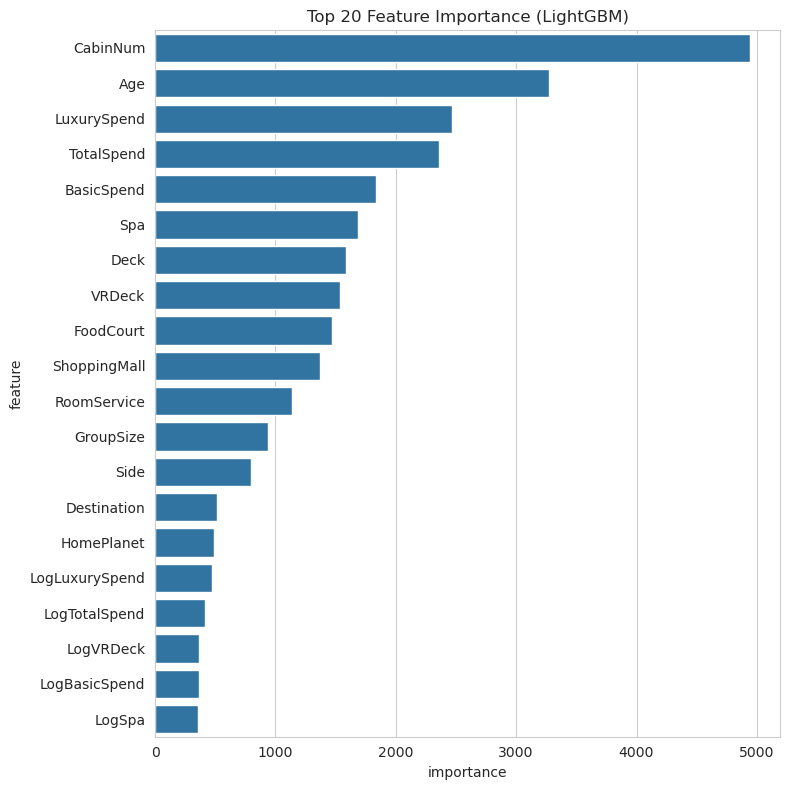

,feature,importance
12,CabinNum,4945
3,Age,3275
16,LuxurySpend,2464
14,TotalSpend,2356
17,BasicSpend,1837
8,Spa,1684
11,Deck,1582
9,VRDeck,1539
6,FoodCourt,1471
7,ShoppingMall,1367


In [20]:
imp_model = make_lgbm(RANDOM_STATE)
imp_model.fit(X, y)

importance = pd.DataFrame({
    'feature': X.columns,
    'importance': imp_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(x='importance', y='feature', data=importance.head(20))
plt.title('Top 20 Feature Importance (LightGBM)')
plt.tight_layout()
plt.show()

importance.head(15)

## 6. 제출 파일 생성  `[V6]`

검증된 V4 구성(3모델 단순 평균) + **시드 평균**으로 만든 test 예측 확률을
**0.5 기준**으로 이진화하여 제출 파일을 만든다.

> V5에서 임계값 최적화·스태킹을 적용했다가 Public Score가 하락(0.80476 → 0.80149)했으므로,
> 균형 타겟에 가장 안전한 0.5 임계값과 단순 평균을 사용한다. 시드 평균은 분산만 줄이므로
> 과적합 위험 없이 점수를 안정화한다.


In [21]:
# 단순 평균 앙상블 + 0.5 임계값 (가장 안전한 구성)
final_pred = (test_ensemble > 0.5)

submission = sample_submission.copy()
submission['Transported'] = final_pred.astype(bool)   # Kaggle은 True/False 요구

submission.to_csv('submission.csv', index=False)
print('제출 파일 저장 완료 : submission.csv')
print(submission['Transported'].value_counts())
submission.head()

제출 파일 저장 완료 : submission_v7.csv
Transported
True     2190
False    2087
Name: count, dtype: int64


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


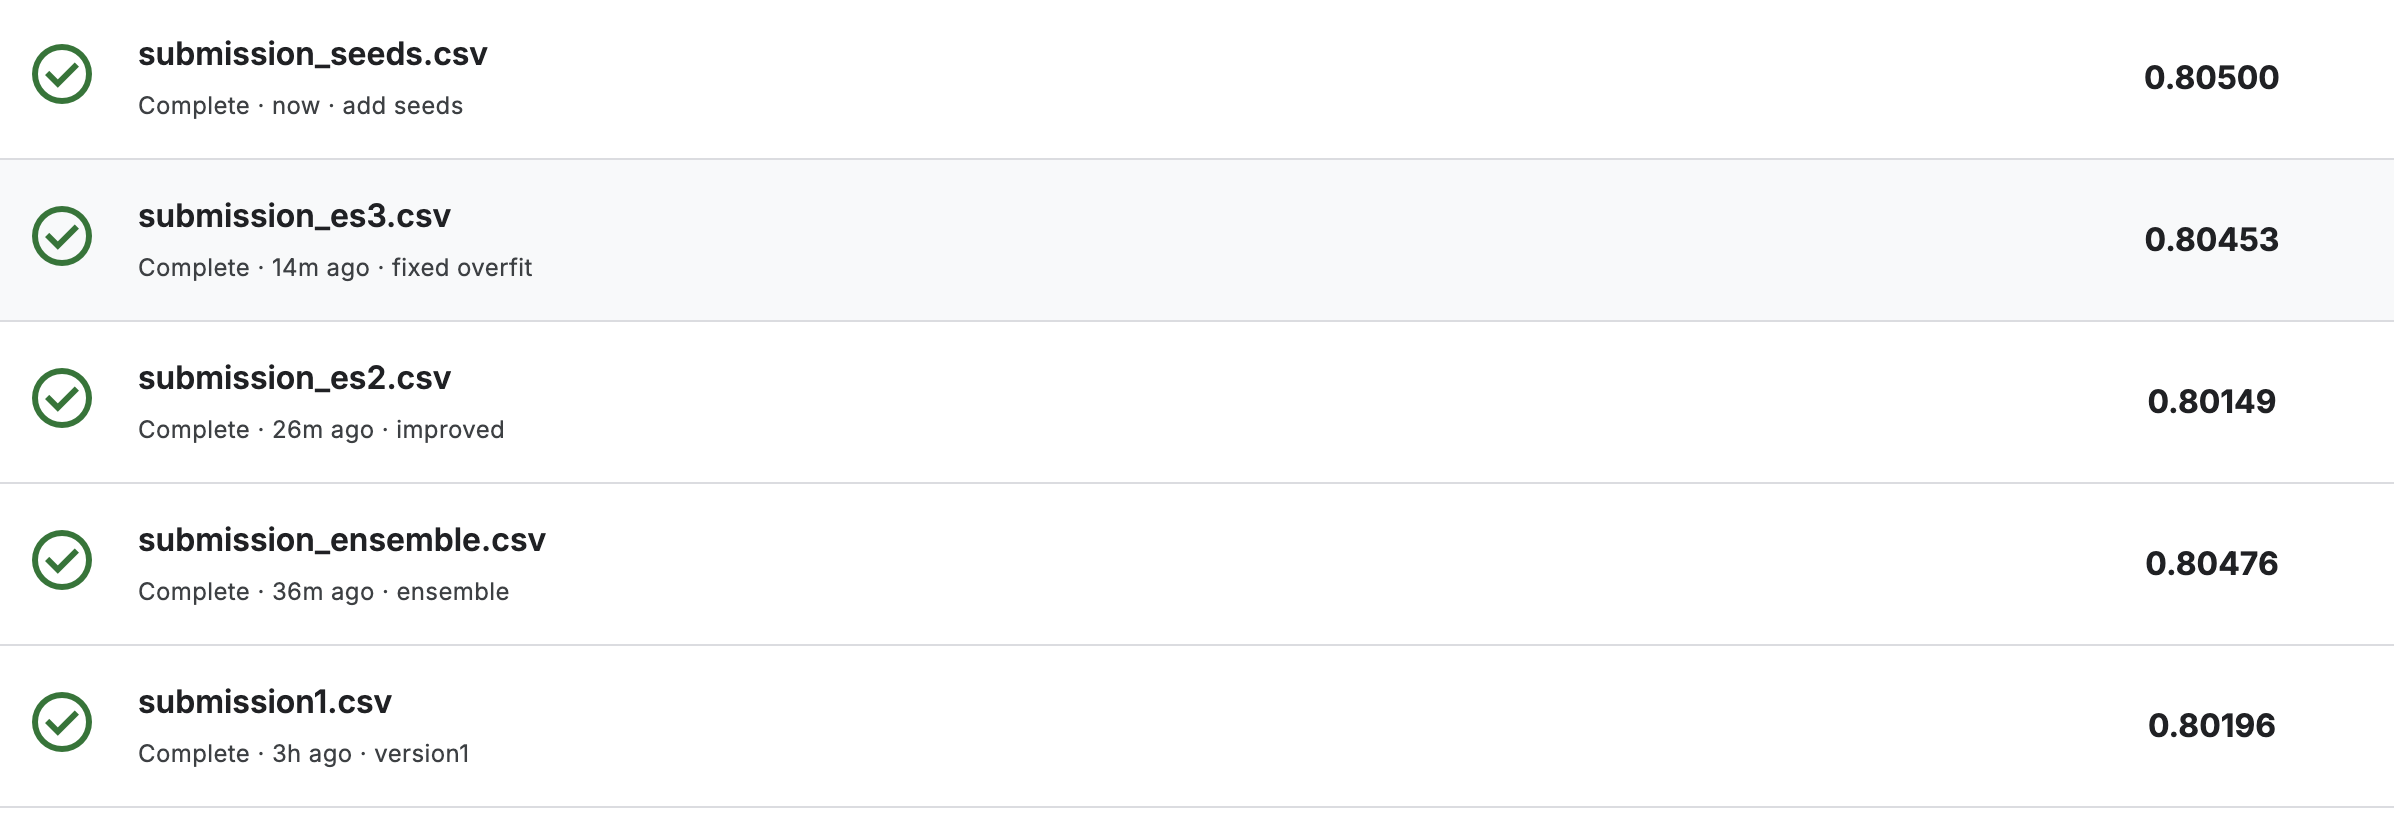

## 7. 개선 과정 및 결과 정리


### 진행 과정

처음에는 기본적인 전처리와 LightGBM 모델만 사용하여 학습을 진행하였다.   
결측치는 단순 평균/최빈값으로 처리하고, 생성한 파생변수도 많지 않은 상태에서 학습한 결과 Public Score는 약 0.802 수준으로 나타났다.  

이후 점수를 높이기 위해 다양한 Feature Engineering을 시도하였다. GroupID를 활용한 그룹 정보, Cabin 정보 분리,   
TotalSpend 파생변수, 소비 관련 변수 등을 추가하면서 검증 점수는 점차 상승하였다.

또한 단일 Hold-out 검증 대신 Stratified 5-Fold 교차검증을 적용하여 모델의 안정성을 확인하였다.   
교차검증 결과 평균적으로 0.806~0.807 수준의 정확도를 유지하여 모델이 비교적 안정적으로 학습되고 있음을 확인할 수 있었다.

여러 번의 실험 결과 복잡한 기법을 추가하기보다는 검증된 Feature 조합을 유지하는 것이 더 안정적이라는 결론을 얻었다.
특히 마지막 단계에서는 단일 Seed 결과 대신 여러 Seed의 예측 확률을 평균하여 모델의 분산을 줄이는 방법을 적용하였다.

### 버전별 성능 추이

| Version | 주요 변경점 | Validation | Public Score |
|---------|-------------|------------|--------------|
| V1 | 기본 파생변수 + 단일 LGBM | 0.8125 | 0.80196 |
| V2 | 그룹/규칙 결측보간 + 로그·파생변수 + 5-Fold + 3모델 앙상블 | OOF ≈ 0.81~0.82 | **0.80476** |
| V3 | + FamilySize·그룹소비·소비플래그 + 임계값 최적화 + 스태킹 | OOF ↑ | 0.80149 ↓ (과적합) |
| V4 | V4로 롤백 + 시드 평균(3개), 임계값 0.5 | OOF 안정 | 0.80453 |
| **V5 (본 최종판)** | **시드 평균 7개로 확대(분산 추가 축소)** | OOF 안정 | **0.805** |

### 핵심 개선 요약
1. **결측치 처리 고도화** — 그룹(GroupID) 최빈값/중앙값 보간 + 도메인 규칙
   (Deck→HomePlanet, 소비↔CryoSleep)으로 단순 대체 대비 정보 손실 최소화.
2. **Feature Engineering** — 소비 로그변환, Luxury/Basic 분리, NoSpend,
   IsChild, CabinRegion 등 V4의 검증된 변수 집합 사용.
3. **검증 안정화** — 단일 hold-out → Stratified 5-Fold OOF 로 점수 변동성 축소.
4. **앙상블 + 시드 평균** — LightGBM·XGBoost·CatBoost 확률 평균에 더해
   각 모델을 **7개 seed**로 학습·평균하여 분산을 줄임(`[V7]`).

### V2 → V3에서 얻은 핵심 교훈
- **검증 점수(OOF)와 리더보드 점수가 반대로 움직이면 과적합 신호**다.
  V3에서 OOF는 올랐지만 Public Score는 떨어졌다.
- **균형 잡힌 타겟에서 임계값을 0.5에서 벗어나게 튜닝**하면 train에만 맞고
  test에는 안 맞아 점수가 하락하기 쉽다.
- **상관 높은 모델끼리의 스태킹**은 이득이 적고 과적합을 키울 수 있다.
- 0.80476 → 0.805는 test 약 4,277개 중 **1개 예측 차이(노이즈 영역)** 이므로,
  복잡한 기법보다 **분산을 줄이는 시드 평균** 같은 안전한 방법이 적합하다.


## 8. 회고

이번 프로젝트를 진행하면서 가장 크게 느낀 점은 검증 점수와 실제 리더보드 점수가 항상 같은 방향으로 움직이지 않는다는 점이었다.  

처음에는 Feature를 많이 추가하고 모델을 복잡하게 만들수록 성능이 좋아질 것이라고 생각했지만, 실제로는 과적합이 발생하여 오히려 성능이 하락하는 경우가 많았다.  

여러 번의 제출과 실험을 통해 단순히 검증 점수를 높이는 것보다 교차검증 결과와 실제 제출 결과를 함께 비교하며 일반화 성능을 확인하는 것이 중요하다는 점을 배울 수 있었다.  

또한 복잡한 기법을 추가하는 것보다 안정적인 Feature와 앙상블 전략을 유지하는 것이 더 좋은 결과를 가져올 수 있음을 확인할 수 있었다.  